<h2 style = "text-align:center;">
Data Analysis
</h2>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [2]:
df = pd.read_csv(r'C:\IDE\Projects\telco-churn-analysis\Data\Cleaned Data.csv')

<h3 style = "text-align:left; text-decoration: underline;">
Overall business KPI's
</h3>

In [3]:
print("Shape:", df.shape)

Shape: (7043, 21)


In [4]:
print("Missing values")
print(df.isnull().sum())

Missing values
customer_id           0
gender                0
senior_citizen        0
partner               0
dependents            0
tenure                0
phone_service         0
multiple_lines        0
internet_service      0
online_security       0
online_backup         0
device_protection     0
tech_support          0
streaming_tv          0
streaming_movies      0
contract              0
paperless_billing     0
payment_method        0
monthly_charges       0
total_charges        11
churn                 0
dtype: int64


In [5]:
total_customers = df["customer_id"].nunique()
churned_customers = (df["churn"] == "Yes").sum()
retained_customers = total_customers - churned_customers
overall_churn_rate = (df["churn"] == "Yes").mean() * 100
avg_tenure = df["tenure"].mean()
avg_monthly_charges = df["monthly_charges"].mean()
avg_total_charges = df["total_charges"].mean()
revenue_at_risk = df[df["churn"] == "Yes"]["monthly_charges"].sum()

In [6]:
print("Total customers:", total_customers)
print("Churned customers:", churned_customers)
print("Retained customers:", retained_customers)
print("Overall churn rate: {:.2f}%".format(overall_churn_rate))
print("Average tenure:", round(avg_tenure, 2))
print("Average monthly charges:", round(avg_monthly_charges, 2))
print("Average total charges:", round(avg_total_charges, 2))
print("Monthly revenue at risk:", round(revenue_at_risk, 2))

Total customers: 7043
Churned customers: 1869
Retained customers: 5174
Overall churn rate: 26.54%
Average tenure: 32.37
Average monthly charges: 64.76
Average total charges: 2283.3
Monthly revenue at risk: 139130.85


<h3 style = "text-align:left; text-decoration: underline;">
Churn Distribution
</h3>

In [7]:
print(df["churn"].value_counts())
print(df["churn"].value_counts(normalize=True) * 100)

churn
No     5174
Yes    1869
Name: count, dtype: int64
churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


<h3 style = "text-align:left; text-decoration: underline;">
Churn Analysis by Contract Type
</h3>

In [8]:
contract_customers = df.groupby("contract")["customer_id"].count()
contract_churn_rate = pd.crosstab(df["contract"], df["churn"], normalize="index")["Yes"] * 100
contract_monthly_revenue_at_risk = df[df["churn"] == "Yes"].groupby("contract")["monthly_charges"].sum()
contract_avg_monthly_charge = df.groupby("contract")["monthly_charges"].mean()
contract_avg_tenure = df.groupby("contract")["tenure"].mean()

In [9]:
contract_analysis = pd.DataFrame({
    "customers": contract_customers,
    "churn_rate": contract_churn_rate,
    "monthly_revenue_at_risk": contract_monthly_revenue_at_risk,
    "avg_monthly_charge": contract_avg_monthly_charge,
    "avg_tenure": contract_avg_tenure
})

In [10]:
contract_analysis = contract_analysis.sort_values("churn_rate", ascending=False)
print(contract_analysis)

                customers  churn_rate  monthly_revenue_at_risk  \
contract                                                         
Month-to-month       3875   42.709677                120847.10   
One year             1473   11.269518                 14118.45   
Two year             1695    2.831858                  4165.30   

                avg_monthly_charge  avg_tenure  
contract                                        
Month-to-month           66.398490   18.036645  
One year                 65.048608   42.044807  
Two year                 60.770413   56.735103  


<h3 style = "text-align:left; text-decoration: underline;">
Churn Analysis by Payment Method
</h3>

In [11]:
payment_customers = df.groupby("payment_method")["customer_id"].count()
payment_churn_rate = pd.crosstab(df["payment_method"], df["churn"], normalize="index")["Yes"] * 100
payment_monthly_revenue_at_risk = df[df["churn"] == "Yes"].groupby("payment_method")["monthly_charges"].sum()
payment_avg_monthly_charge = df.groupby("payment_method")["monthly_charges"].mean()
payment_avg_tenure = df.groupby("payment_method")["tenure"].mean()

In [12]:
payment_analysis = pd.DataFrame({
    "customers": payment_customers,
    "churn_rate": payment_churn_rate,
    "monthly_revenue_at_risk": payment_monthly_revenue_at_risk,
    "avg_monthly_charge": payment_avg_monthly_charge,
    "avg_tenure": payment_avg_tenure
})

In [13]:
payment_analysis = payment_analysis.sort_values("churn_rate", ascending=False)
print(payment_analysis)

                           customers  churn_rate  monthly_revenue_at_risk  \
payment_method                                                              
Electronic check                2365   45.285412                 84288.75   
Mailed check                    1612   19.106700                 16803.60   
Bank transfer (automatic)       1544   16.709845                 20091.90   
Credit card (automatic)         1522   15.243101                 17946.60   

                           avg_monthly_charge  avg_tenure  
payment_method                                             
Electronic check                    76.255814   25.174630  
Mailed check                        43.917060   21.830025  
Bank transfer (automatic)           67.192649   43.656736  
Credit card (automatic)             66.512385   43.269382  


<h3 style = "text-align:left; text-decoration:underline;">
Churn Analysis by Internet Service
<h3>

In [14]:
internet_customers = df.groupby("internet_service")["customer_id"].count()
internet_churn_rate = pd.crosstab(df["internet_service"], df["churn"], normalize="index")["Yes"] * 100
internet_monthly_revenue_at_risk = df[df["churn"] == "Yes"].groupby("internet_service")["monthly_charges"].sum()
internet_avg_monthly_charge = df.groupby("internet_service")["monthly_charges"].mean()
internet_avg_tenure = df.groupby("internet_service")["tenure"].mean()

In [15]:
internet_analysis = pd.DataFrame({
    "customers": internet_customers,
    "churn_rate": internet_churn_rate,
    "monthly_revenue_at_risk": internet_monthly_revenue_at_risk,
    "avg_monthly_charge": internet_avg_monthly_charge,
    "avg_tenure": internet_avg_tenure
})

In [16]:
internet_analysis = internet_analysis.sort_values("churn_rate", ascending=False)
print(internet_analysis)

                  customers  churn_rate  monthly_revenue_at_risk  \
internet_service                                                   
Fiber optic            3096   41.892765                114300.05   
DSL                    2421   18.959108                 22529.20   
No                     1526    7.404980                  2301.60   

                  avg_monthly_charge  avg_tenure  
internet_service                                  
Fiber optic                91.500129   32.917959  
DSL                        58.102169   32.821561  
No                         21.079194   30.547182  


<h3 style = "text-align:left; text-decoration:underline;">
Churn Analysis by Senior Citizen Status
</h3>

In [17]:
senior_customers = df.groupby("senior_citizen")["customer_id"].count()
senior_churn_rate = pd.crosstab(df["senior_citizen"], df["churn"], normalize="index")["Yes"] * 100
senior_monthly_revenue_at_risk = df[df["churn"] == "Yes"].groupby("senior_citizen")["monthly_charges"].sum()
senior_avg_monthly_charge = df.groupby("senior_citizen")["monthly_charges"].mean()
senior_avg_tenure = df.groupby("senior_citizen")["tenure"].mean()

In [18]:
senior_analysis = pd.DataFrame({
    "customers": senior_customers,
    "churn_rate": senior_churn_rate,
    "monthly_revenue_at_risk": senior_monthly_revenue_at_risk,
    "avg_monthly_charge": senior_avg_monthly_charge,
    "avg_tenure": senior_avg_tenure
})

In [19]:
senior_analysis = senior_analysis.sort_values("churn_rate", ascending=False)
print(senior_analysis)

                customers  churn_rate  monthly_revenue_at_risk  \
senior_citizen                                                   
1                    1142   41.681261                 38419.60   
0                    5901   23.606168                100711.25   

                avg_monthly_charge  avg_tenure  
senior_citizen                                  
1                        79.820359   33.295972  
0                        61.847441   32.192171  


<h3 style = "text-align:left; text-decoration:underline;">
Churn Analysis by Paperless Billing
</h3>

In [20]:
paperless_customers = df.groupby("paperless_billing")["customer_id"].count()
paperless_churn_rate = pd.crosstab(df["paperless_billing"], df["churn"], normalize="index")["Yes"] * 100
paperless_monthly_revenue_at_risk = df[df["churn"] == "Yes"].groupby("paperless_billing")["monthly_charges"].sum()
paperless_avg_monthly_charge = df.groupby("paperless_billing")["monthly_charges"].mean()
paperless_avg_tenure = df.groupby("paperless_billing")["tenure"].mean()

In [21]:
paperless_analysis = pd.DataFrame({
    "customers": paperless_customers,
    "churn_rate": paperless_churn_rate,
    "monthly_revenue_at_risk": paperless_monthly_revenue_at_risk,
    "avg_monthly_charge": paperless_avg_monthly_charge,
    "avg_tenure": paperless_avg_tenure
})

In [22]:
paperless_analysis = paperless_analysis.sort_values("churn_rate", ascending=False)
print(paperless_analysis)

                   customers  churn_rate  monthly_revenue_at_risk  \
paperless_billing                                                   
Yes                     4171   33.565092                109510.00   
No                      2872   16.330084                 29620.85   

                   avg_monthly_charge  avg_tenure  
paperless_billing                                  
Yes                         73.553776   32.496524  
No                          51.992967   32.189067  


<h3 style = "text-align:left; text-decoration:underline;">
Customer Relationship Analysis
</h3>

In [23]:
partner_churn_rate = pd.crosstab(df["partner"], df["churn"], normalize="index")["Yes"] * 100
dependents_churn_rate = pd.crosstab(df["dependents"], df["churn"], normalize="index")["Yes"] * 100

In [24]:
print("Partner Churn Rate")
print(partner_churn_rate.sort_values(ascending=False))

Partner Churn Rate
partner
No     32.957979
Yes    19.664903
Name: Yes, dtype: float64


In [25]:
print("Dependents Churn Rate")
print(dependents_churn_rate.sort_values(ascending=False))

Dependents Churn Rate
dependents
No     31.279140
Yes    15.450237
Name: Yes, dtype: float64


<h3 style = "text-align:left; text-decoration:underline;">
Support Services Analysis
</h3>

In [26]:
online_security_churn_rate = pd.crosstab(df["online_security"], df["churn"], normalize="index")["Yes"] * 100
tech_support_churn_rate = pd.crosstab(df["tech_support"], df["churn"], normalize="index")["Yes"] * 100

In [27]:
print("Online Security Churn Rate")
print(online_security_churn_rate.sort_values(ascending=False))

Online Security Churn Rate
online_security
No                     41.766724
Yes                    14.611194
No internet service     7.404980
Name: Yes, dtype: float64


In [28]:
print("Tech Support Churn Rate")
print(tech_support_churn_rate.sort_values(ascending=False))

Tech Support Churn Rate
tech_support
No                     41.635474
Yes                    15.166341
No internet service     7.404980
Name: Yes, dtype: float64


<h3 style = "text-align:left; text-decoration:underline;">
Churned vs Retained Customer Comparison
</h3>

In [29]:
monthly_charge_by_churn = df.groupby("churn")["monthly_charges"].mean()
tenure_by_churn = df.groupby("churn")["tenure"].mean()
total_charges_by_churn = df.groupby("churn")["total_charges"].mean()

In [30]:
print("Average Monthly Charges by Churn")
print(monthly_charge_by_churn)

Average Monthly Charges by Churn
churn
No     61.265124
Yes    74.441332
Name: monthly_charges, dtype: float64


In [31]:
print("Average Tenure by Churn")
print(tenure_by_churn)

Average Tenure by Churn
churn
No     37.569965
Yes    17.979133
Name: tenure, dtype: float64


In [32]:
print("Average Total Charges by Churn")
print(total_charges_by_churn)

Average Total Charges by Churn
churn
No     2555.344141
Yes    1531.796094
Name: total_charges, dtype: float64


<h3 style = "text-align:left; text-decoration:underline;">
High Value Customer Risk Analysis
</h3>

In [33]:
high_value_customers = df[df["monthly_charges"] >= df["monthly_charges"].median()]
high_value_churn_rate = (high_value_customers["churn"] == "Yes").mean() * 100
high_value_revenue_at_risk = high_value_customers[high_value_customers["churn"] == "Yes"]["monthly_charges"].sum()

In [34]:
print("High Value Customer Churn Rate:", round(high_value_churn_rate, 2), "%")
print("High Value Monthly Revenue at Risk:", round(high_value_revenue_at_risk, 2))

High Value Customer Churn Rate: 35.13 %
High Value Monthly Revenue at Risk: 110455.75


<h3 style = "text-align:left; text-decoration:underline;">
Seaborn Visual Analysis
</h3>

In [35]:
sns.set_style("whitegrid")

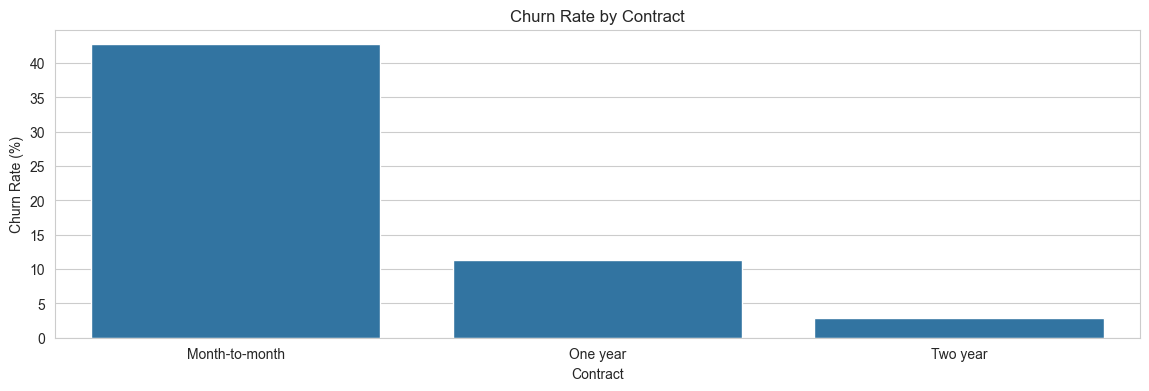

In [36]:
contract_plot = contract_analysis.reset_index()
plt.figure(figsize=(14, 4))
sns.barplot(data=contract_plot, x="contract", y="churn_rate")
plt.title("Churn Rate by Contract")
plt.xlabel("Contract")
plt.ylabel("Churn Rate (%)")
plt.show()

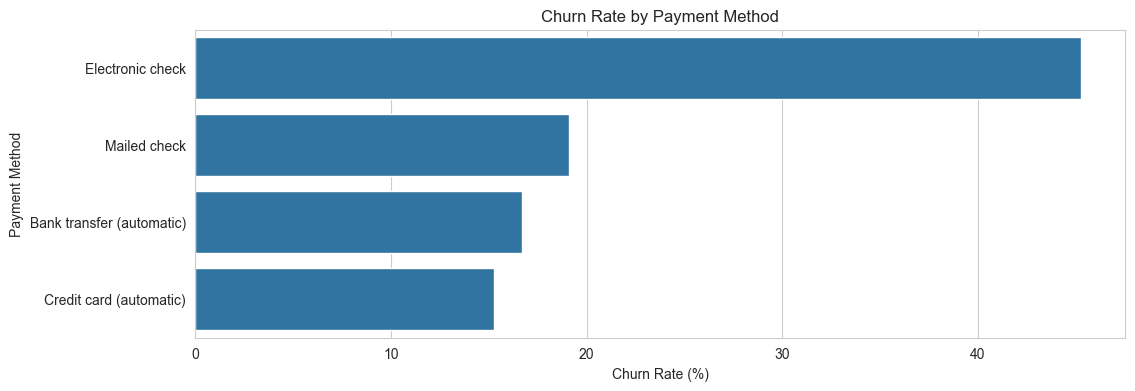

In [37]:
payment_plot = payment_analysis.reset_index()
plt.figure(figsize=(12, 4))
sns.barplot(data=payment_plot, x="churn_rate", y="payment_method")
plt.title("Churn Rate by Payment Method")
plt.xlabel("Churn Rate (%)")
plt.ylabel("Payment Method")
plt.show()

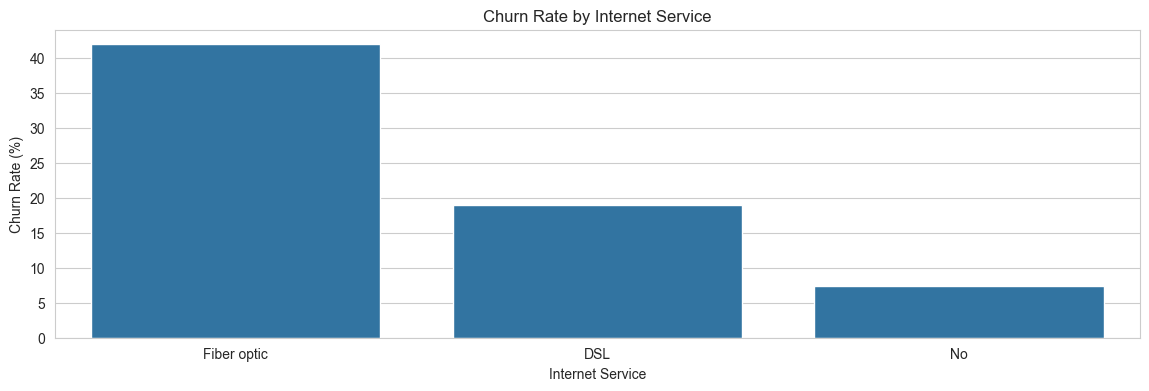

In [38]:
internet_plot = internet_analysis.reset_index()
plt.figure(figsize=(14, 4))
sns.barplot(data=internet_plot, x="internet_service", y="churn_rate")
plt.title("Churn Rate by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Churn Rate (%)")
plt.show()

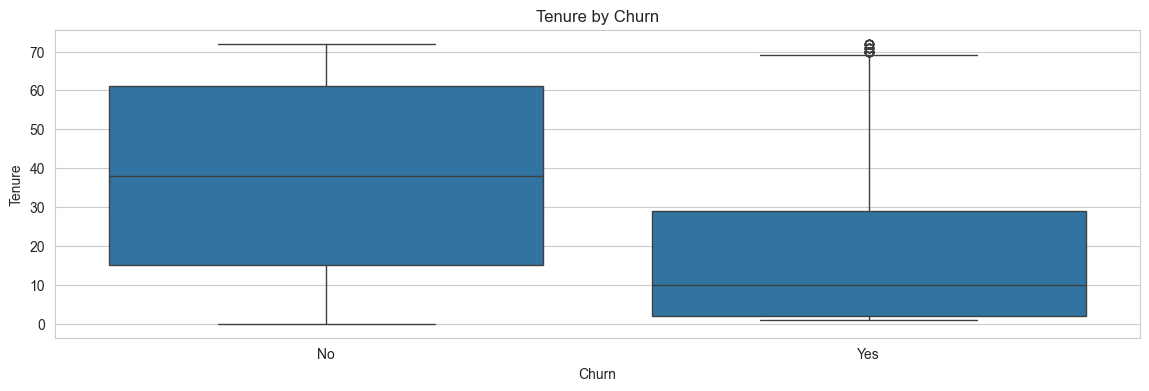

In [39]:
plt.figure(figsize=(14, 4))
sns.boxplot(data=df, x="churn", y="tenure")
plt.title("Tenure by Churn")
plt.xlabel("Churn")
plt.ylabel("Tenure")
plt.show()

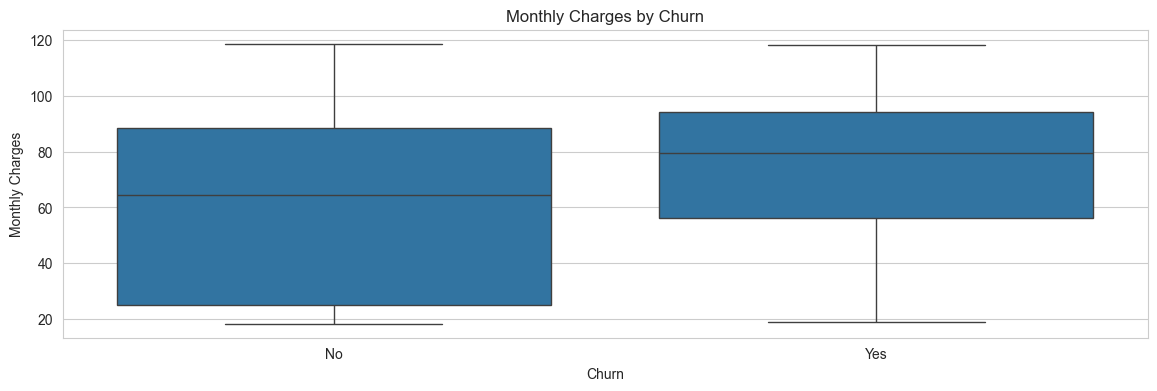

In [40]:
plt.figure(figsize=(14, 4))
sns.boxplot(data=df, x="churn", y="monthly_charges")
plt.title("Monthly Charges by Churn")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")
plt.show()

<h3 style = "text-align:left; text-decoration:underline;">
Plotly Interactive Charts
</h3>

In [41]:
fig = px.bar(
    contract_plot,
    x="contract",
    y="churn_rate",
    text="churn_rate",
    title="Churn Rate by Contract"
)
fig.show()

In [42]:
fig = px.bar(
    payment_plot,
    x="payment_method",
    y="churn_rate",
    text="churn_rate",
    title="Churn Rate by Payment Method"
)
fig.show()

In [43]:
fig = px.bar(
    internet_plot,
    x="internet_service",
    y="churn_rate",
    text="churn_rate",
    title="Churn Rate by Internet Service"
)
fig.show()

In [44]:
fig = px.scatter(
    df,
    x="tenure",
    y="monthly_charges",
    color="churn",
    title="Tenure vs Monthly Charges by Churn"
)
fig.show()

<h3 style = "text-align:left; text-decoration:underline;">
Key Business Insights
</h3>

- Month-to-month customers are likely to have the highest churn risk.
- Customers using electronic check payment may need closer attention.
- Customers with fiber optic internet may show higher churn behavior.
- Short-tenure customers are more likely to churn than long-tenure customers.
- High monthly charge customers should be monitored because they represent revenue risk.
- Revenue at risk should be reviewed by contract type, payment method, and internet service.